# CGAN Data Augmentation – Panoramica
Flusso completo per generare campioni sintetici delle classi rare (DISGUST, SURPRISE, NEUTRAL) con un Conditional GAN: mount Drive → load dataset → individuazione classi rare → preparazione dati → definizione modelli → training → generazione sintetici → salvataggi e check qualitativi.

## Section 1: Monta Google Drive
Necessario per leggere il dataset e salvare modelli/output su Drive.

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Section 2: Import e check GPU
Importa TensorFlow/NumPy, controlla versione e disponibilità GPU.

In [5]:
import tensorflow as tf
import numpy as np
import random
import matplotlib.pyplot as plt
import h5py, os

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
print('TF', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TF 2.19.0
GPU available: True


## Section 3: Caricamento dataset HDF5
Carica train/val da `dataset.h5` e unisce i due split per l'analisi.

In [6]:
DATASET_PATH = '/content/drive/MyDrive/TESI POLITO/dataset/dataset/dataset.h5'
with h5py.File(DATASET_PATH, 'r') as f:
    X_train = np.array(f['X_train'])
    y_train = np.array(f['y_train'])
    X_val = np.array(f['X_val'])
    y_val = np.array(f['y_val'])
    class_names = [c.decode('utf-8') for c in f['class_names']]
X = np.concatenate([X_train, X_val])
y = np.concatenate([y_train, y_val])
print('Shapes', X.shape, y.shape)

Shapes (26605, 128, 128, 3) (26605,)


## Section 4: Individuazione classi rare
Trova classi con frequenza <15% della classe più numerosa e visualizza la distribuzione.

Rare classes: {np.int64(1): 'DISGUST', np.int64(6): 'SURPRISE'}
ANGRY     : 3286
DISGUST   : 642
FEAR      : 2843
HAPPY     : 13742
NEUTRAL   : 2457
SAD       : 2848
SURPRISE  : 787


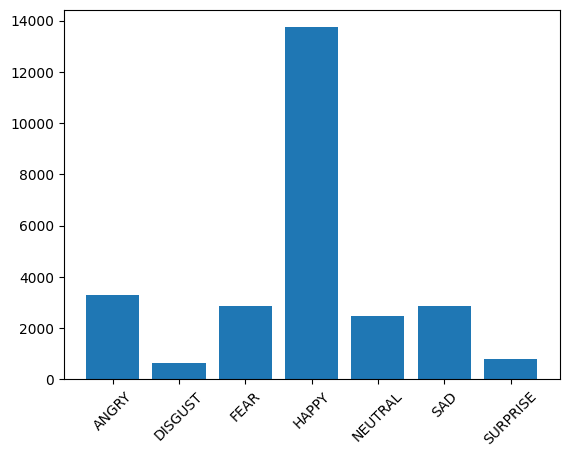

In [7]:
counts = np.bincount(y)
max_count = counts.max()
rare_idx = np.where(counts < 0.15 * max_count)[0]
rare_names = [class_names[i] for i in rare_idx]
print('Rare classes:', dict(zip(rare_idx, rare_names)))
for i, n in enumerate(class_names):
    print(f'{n:10s}: {counts[i]}')
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.show()

## Section 5: Prepara subset classi rare
Filtra solo le classi rare, normalizza in [-1,1], rimappa etichette a indice locale e applica one-hot.

In [8]:
mask = np.isin(y, rare_idx)
X_rare = X[mask].astype('float32') / 127.5 - 1.0
y_rare = y[mask]
label_map = {old:new for new, old in enumerate(rare_idx)}
y_remap = np.array([label_map[v] for v in y_rare])
num_classes = len(rare_idx)
y_onehot = tf.keras.utils.to_categorical(y_remap, num_classes)
print('Rare subset', X_rare.shape, y_onehot.shape)

Rare subset (1429, 128, 128, 3) (1429, 2)


In [29]:
print("rare_idx:", rare_idx, "len:", len(rare_idx))
print("mask sum (num rare samples):", mask.sum())
print("X_rare shape/dtype/min/max:", X_rare.shape, X_rare.dtype, X_rare.min(), X_rare.max())
print("y_onehot shape:", y_onehot.shape)
print("class_names:", class_names)

rare_idx: [1 6] len: 2
mask sum (num rare samples): 1429
X_rare shape/dtype/min/max: (1429, 128, 128, 3) float32 -1.0 1.0
y_onehot shape: (1429, 2)
class_names: ['ANGRY', 'DISGUST', 'FEAR', 'HAPPY', 'NEUTRAL', 'SAD', 'SURPRISE']


## Section 6: Hyperparameter setup
Definisci dimensione immagine, latente, batch e LR per Adam.

In [11]:
IMG_SHAPE = (128,128,3)
NOISE_DIM = 64
BATCH_SIZE = 16
LR_D = 1e-4
LR_G = 1e-4
BETA1 = 0.5
D_STEPS = 1  # train D twice per batch to keep it competitive
REAL_SMOOTH = 0.9  # label smoothing for real labels

## Section 7: Definizione modelli CGAN
Generator: noise+label → immagine. Discriminator condizionato: immagine+label → real/fake. Compila D con BCE, blocca D nel modello combinato per allenare G.

In [12]:
def build_generator():
    noise = tf.keras.Input(shape=(NOISE_DIM,))
    label = tf.keras.Input(shape=(num_classes,))
    x = tf.keras.layers.Concatenate()([noise, label])
    x = tf.keras.layers.Dense(16*16*128, activation='relu')(x)
    x = tf.keras.layers.Reshape((16,16,128))(x)
    for f in [128,64,32]:
        x = tf.keras.layers.Conv2DTranspose(f, 4, strides=2, padding='same', activation='relu')(x)
        x = tf.keras.layers.BatchNormalization()(x)
    out = tf.keras.layers.Conv2D(3, 3, padding='same', activation='tanh')(x)
    return tf.keras.Model([noise, label], out)


def build_discriminator():
    img = tf.keras.Input(shape=IMG_SHAPE)
    label = tf.keras.Input(shape=(num_classes,))
    l = tf.keras.layers.Reshape((1,1,num_classes))(label)
    l = tf.keras.layers.UpSampling2D(size=(IMG_SHAPE[0], IMG_SHAPE[1]))(l)
    x = tf.keras.layers.Concatenate()([img, l])
    for f in [64,128,256]:
        x = tf.keras.layers.Conv2D(f, 4, strides=2, padding='same')(x)
        x = tf.keras.layers.LeakyReLU(0.2)(x)
        x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Flatten()(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    return tf.keras.Model([img, label], out)


G = build_generator()
D = build_discriminator()
D.compile(optimizer=tf.keras.optimizers.Adam(LR_D, beta_1=BETA1), loss='binary_crossentropy', metrics=['accuracy'])
noise_in = tf.keras.Input(shape=(NOISE_DIM,))
label_in = tf.keras.Input(shape=(num_classes,))
fake_img = G([noise_in, label_in])
D.trainable = False
valid = D([fake_img, label_in])
GAN = tf.keras.Model([noise_in, label_in], valid)
GAN.compile(optimizer=tf.keras.optimizers.Adam(LR_G, beta_1=BETA1), loss='binary_crossentropy')
G.summary(); D.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 66)        │          0 │ input_layer_6[0]… │
│ (Concatenate)       │                   │            │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32768)     │  2,195,456 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 16, 16,    │          0 │ dense_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_3  │ (None, 32, 32,    │    262,272 │ reshape_2[0][0]   │
│ (Conv2DTranspose)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_4  │ (None, 64, 64,    │    131,136 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_5  │ (None, 128, 128,  │     32,800 │ batch_normalizat… │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_transpose… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 128, 128,  │        867 │ batch_normalizat… │
│                     │ 3)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,623,427 (10.01 MB)

 Trainable params: 2,622,979 (10.01 MB)

 Non-trainable params: 448 (1.75 KB)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 1, 1, 2)   │          0 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ reshape_3[0][0]   │
│ (UpSampling2D)      │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 128, 128,  │          0 │ input_layer_8[0]… │
│ (Concatenate)       │ 5)                │            │ up_sampling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │      5,184 │ concatenate_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_3       │ (None, 64, 64,    │          0 │ conv2d_5[0][0]    │
│ (LeakyReLU)         │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64, 64,    │          0 │ leaky_re_lu_3[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    131,200 │ dropout_3[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_4       │ (None, 32, 32,    │          0 │ conv2d_6[0][0]    │
│ (LeakyReLU)         │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 32, 32,    │          0 │ leaky_re_lu_4[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    524,544 │ dropout_4[0][0]   │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_5       │ (None, 16, 16,    │          0 │ conv2d_7[0][0]    │
│ (LeakyReLU)         │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 16, 16,    │          0 │ leaky_re_lu_5[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 65536)     │          0 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │     65,537 │ flatten_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 726,465 (2.77 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 726,465 (2.77 MB)

## Section 8: Training loop (2:1 D/G, label smoothing)
Allena il discriminatore due volte per batch con smoothing sui real (0.9) e poi aggiorna il generatore; logga le loss.

/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:83: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 20/20 - D: 2.495 - G: 0.054


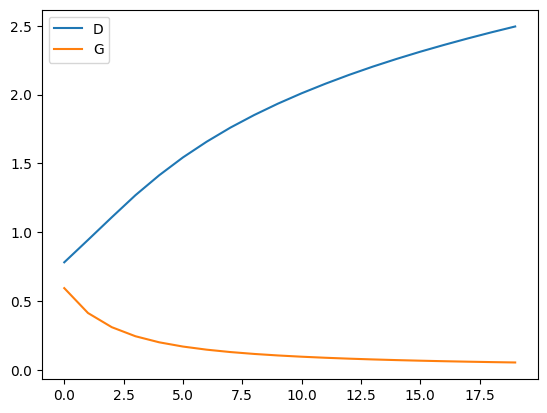

In [13]:
def train(epochs=200):
    d_hist, g_hist = [], []
    ds = tf.data.Dataset.from_tensor_slices((X_rare, y_onehot)).shuffle(len(X_rare), seed=42).batch(BATCH_SIZE)
    for epoch in range(epochs):
        d_loss_epoch = g_loss_epoch = 0.0
        steps = 0
        for real_imgs, labels in ds:
            bs = real_imgs.shape[0]
            # D steps (keep D competitive)
            real_imgs_noisy = tf.clip_by_value(real_imgs + tf.random.normal(tf.shape(real_imgs), stddev=0.02), -1.0, 1.0)
            d_step_loss = 0.0
            for _ in range(D_STEPS):
                noise = tf.random.normal((bs, NOISE_DIM))
                fake_imgs = G([noise, labels], training=True)
                fake_imgs_noisy = tf.clip_by_value(fake_imgs + tf.random.normal(tf.shape(fake_imgs), stddev=0.02), -1.0, 1.0)
                real_y = tf.ones((bs,1)) * REAL_SMOOTH
                fake_y = tf.zeros((bs,1))
                d_loss_real = D.train_on_batch([real_imgs_noisy , labels], real_y)[0]
                d_loss_fake = D.train_on_batch([fake_imgs_noisy, labels], fake_y)[0]
                d_step_loss += 0.5 * (d_loss_real + d_loss_fake)
            d_loss = d_step_loss / D_STEPS
            # G step (tries to fool D)
            noise = tf.random.normal((bs, NOISE_DIM))
            g_target = tf.ones((bs,1))
            g_loss = GAN.train_on_batch([noise, labels], g_target)
            d_loss_epoch += d_loss; g_loss_epoch += g_loss; steps += 1
        d_hist.append(d_loss_epoch/steps); g_hist.append(g_loss_epoch/steps)
        if (epoch+1) % 20 == 0:
            print(f'Epoch {epoch+1}/{epochs} - D: {d_hist[-1]:.3f} - G: {g_hist[-1]:.3f}')
    return d_hist, g_hist

d_losses, g_losses = train(epochs=20)
plt.plot(d_losses, label='D'); plt.plot(g_losses, label='G'); plt.legend(); plt.show()

## Section 9: Generazione sintetici
Per ogni classe rara genera campioni (≈25% del max), denormalizza a uint8 per salvataggio.

In [14]:
target_per_class = int(max_count * 0.25)
synth_images = []
synth_labels = []
for cid in range(num_classes):
    noise = tf.random.normal((target_per_class, NOISE_DIM))
    labels = np.zeros((target_per_class, num_classes), dtype=np.float32)
    labels[:, cid] = 1
    imgs = G.predict([noise, labels], verbose=0)
    synth_images.append(imgs)
    synth_labels += [cid]*target_per_class
synth_images = np.concatenate(synth_images)
synth_images_uint8 = ((synth_images + 1)/2 * 255).astype(np.uint8)
synth_labels = np.array(synth_labels)
print('Synthetic set', synth_images_uint8.shape, synth_labels.shape)

Synthetic set (6870, 128, 128, 3) (6870,)


## Section 10: Anteprima sintetici
Visualizza una griglia di esempi generati per controllo qualitativo.

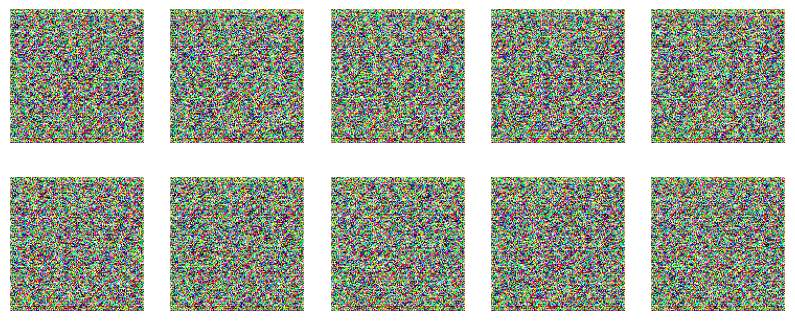

In [15]:
fig, ax = plt.subplots(2,5, figsize=(10,4))
for i in range(10):
    r, c = divmod(i,5)
    ax[r,c].imshow(synth_images_uint8[i])
    ax[r,c].axis('off')
plt.show()

## Section 11: Salvataggio modelli e dataset sintetico
Salva generator/discriminator e i file `.npy` (immagini, etichette, indici classi rare) su Drive.

In [ ]:
OUT_DIR = '/content/drive/MyDrive/GAN_augmentation'
os.makedirs(OUT_DIR, exist_ok=True)
G.save(os.path.join(OUT_DIR, 'generator_cgan.h5'))
D.save(os.path.join(OUT_DIR, 'discriminator_cgan.h5'))
np.save(os.path.join(OUT_DIR, 'synthetic_images.npy'), synth_images_uint8)
np.save(os.path.join(OUT_DIR, 'synthetic_labels.npy'), synth_labels)
np.save(os.path.join(OUT_DIR, 'rare_class_indices.npy'), rare_idx)
print('Saved to', OUT_DIR)